In [166]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

import pandas as pd
import numpy as np

In [167]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
from nltk import ngrams
from gensim.models import Word2Vec

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,ConfusionMatrixDisplay,confusion_matrix,precision_score,accuracy_score

from sklearn.preprocessing import MinMaxScaler,MaxAbsScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB

from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
import pickle
import re

### Loading datasets

In [168]:
df = pd.read_csv('../spam_Emails_data.csv',nrows=20000)
df.head()

,label,text
0,Spam,viiiiiiagraaaa\nonly for the ones that want to...
1,Ham,got ice thought look az original message ice o...
2,Spam,yo ur wom an ne eds an escapenumber in ch ma n...
3,Spam,start increasing your odds of success & live s...
4,Ham,author jra date escapenumber escapenumber esca...


In [169]:
df['text'][1]

'got ice thought look az original message ice operations mailto iceoperations intcx com sent friday october escapenumber escapenumber escapenumber escapenumber pm subject escapelong amended participant agreement dear participant receiving email identified company user administrator legal counsel signatory escapelong participant agreement serves notice intercontinentals intent amend agreement effective december escapenumber escapenumber relevant documentation attached includes contact information questions thank escapelong inc'

In [170]:
df['label'].value_counts()

label
Ham     10592
Spam     9408
Name: count, dtype: int64

In [171]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])

In [172]:
df['label'].value_counts()

label
0    10592
1     9408
Name: count, dtype: int64

In [173]:
df.shape

(20000, 2)

In [174]:
df['text'][5]

'img src escapenumberd http loan co kr img email imgescapenumber gif width escapenumberd escapenumber height escapenumberd escapenumber border escapenumberd escapenumber img src escapenumberd http loan co kr img email imgescapenumber gif width escapenumberd escapenumber height escapenumberd escapenumber border escapenumberd escapenumber img src escapenumberd http loan co kr img email imgescapenumber gif width escapenumberd escapenumber height escapenumberd escapenumber border escapenumberd escapenumber img src escapenumberd http loan co kr img email imgescapenumber gif width escapenumberd escapenumber height escapenumberd escapenumber border escapenumberd escapenumber hkxtattw x ikybkwdowkikjgzgznk ybreilxqd qfr rrpcckwlipgog'

In [175]:
df.duplicated().sum()

np.int64(0)

In [176]:
df = df.drop_duplicates(keep='first')

In [177]:
df.isnull().sum()

label    0
text     0
dtype: int64

In [178]:
df=df.dropna()
df.shape

(20000, 2)

### EDA

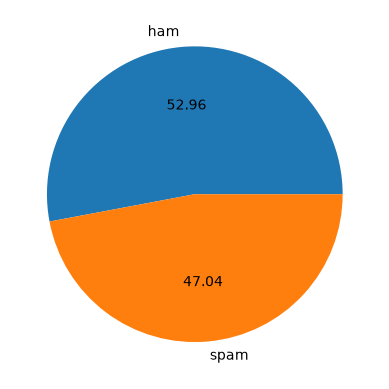

In [179]:
plt.pie(df['label'].value_counts(),autopct='%.2f',labels=['ham','spam'])
plt.show()

### Individual Function for text preprocessing
Replacing chat short words like gm = good morning, wkly= weekly

In [180]:

import import_ipynb
from vocabulary import Words_dict

def short_word_converter(text):
    final_text = []
    for words in re.split(r"[ ,;())|.]+",text):
        if words in Words_dict():
            final_text.append(Words_dict[words])
        else:
            final_text.append(words)
    return " ".join(final_text).strip()

Replacing english contractions words to full word like don't = do not

In [181]:
def full_form(text):
    full_text = []
    for words in text.split():
        if words in Words_dict:
            full_text.append(Words_dict[words])
        else:
            full_text.append(words)
    return " ".join(full_text)

Replacing What's App chat words with their meaning word

In [182]:
def whatsapp_word_converter(text):
    final_text = []
    for words in re.split(r"[ ,;())|.]+", text):
        if words in Words_dict:
            final_text.append(Words_dict[words])
        else:
            final_text.append(words)
    return " ".join(final_text)

Removing digits and punctuations

In [183]:
def remove_digits_and_punctuation(text):
    text = re.sub(r"\d+", "",str(text))     # remove digits
    text =text.translate(str.maketrans("","",string.punctuation))   # remove punctuation
    return text.strip()

Converting suffix and preffix words into their fullform

In [184]:
def suffix_words(text):
    final_text = []
    for words in text.split():
        if words in Words_dict:
            final_text.append(Words_dict[words])
        else:
            final_text.append(words)
    return " ".join(final_text)

Removing Non-english words

In [185]:
import nltk
from nltk.corpus import words as nltk_words

In [186]:
def english_words_only(text):
    words_list = str(text).split()
    only_english_words = [w for w in words_list if w.isascii()]
    return " ".join(only_english_words)

Removing Stopwords

In [187]:
from nltk.corpus import stopwords

def remove_stopwords(text):
    non_stopwords = []
    for words in text.split():
        if words in stopwords.words('english'):
            non_stopwords.append("")
        else:
             non_stopwords.append(words)
    return re.sub(r"\s+"," "," ".join(non_stopwords))

Stemming: Converting words into their baseform

In [188]:
from nltk.stem import PorterStemmer, WordNetLemmatizer
wnl =  WordNetLemmatizer()

def baseform(text):
    final_text = []
    for words in text.split():
        v_text = wnl.lemmatize(words,pos='v') #verb : converting words into their baseform
        n_text = wnl.lemmatize(v_text,pos='n') #noun : converting words like cars to baseform
        a_text = wnl.lemmatize(n_text,pos='a') #adjective : converting words like better to good
        final_text.append(a_text)

    return " ".join(final_text)

Removing repeated characters

### All in One Function for Text Preprocessin

In [189]:
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/fahimp/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/fahimp/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [190]:
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer,WordNetLemmatizer
from nltk.tokenize import word_tokenize,sent_tokenize

# Initialize 
wnl = WordNetLemmatizer()
stopwords_list = set(stopwords.words('english'))

# One Function for all text preprocessing
def text_preprocessing(text):
    #Clean text
    text = re.sub(r"\d+","",str(text))
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = text.lower()

    # Tokenize and process 
    tokens = text.split()
    processed_tokens = []

    for token in tokens:
        # Keep only ASCII words
        if not token.isascii():
            continue

        # Remove stopwords
        if token in stopwords_list:
            continue

        # Handle contractions 
        if token in Words_dict:
            token = Words_dict[token]

        # Lemmatization
        token = wnl.lemmatize(token, pos='v')
        token = wnl.lemmatize(token, pos='n')
        token = wnl.lemmatize(token, pos='a')

        # Keep words with length >=2
        if len(token) >=2:
            processed_tokens.append(token)

    # Join and clean
    final_output = " ".join(processed_tokens)
    final_output = re.sub(F'\s+'," ",final_output)
    final_output = re.sub(r"(.)\1{3,}",r"\1\1",final_output)


    return final_output.strip()

In [191]:
df['text'][5045]

'attn - sir\nhague questry lottery\nbonpostraat 26\n7651 am groningen\nthe netherlands .\nfrom : the desk of the promotions manager ,\ninternational promotions / prize award department ,\nref : tlot / 33900560 / 04\nbatch : 24 / ai 90061 / 8482 / ui\nattention :\nre / award notification ; final notice\nwe are pleased to inform you of the announcement today , 8 th october , 2004\nof winners of the the hague questry promo lottery , the netherlands /\ninternational , programs held on 28 th september , 2004 .\nyour email address , is attached to a ticket number , with serial number 4399 - 11 and the\nlucky numbers preserved and insured\nfor strict award distinct , identifying your lottery award in the 3 rd category\nyou have therefore been approved for a lump sum pay out of\nus $ 5 , 500 . 000 . 00 in cash credited to file ref no . tlot / 33900560 / 04 . this is from\ntotal prize money of us $ 80 , 400 , 000 . 00 shared among the seventeen\ninternational winners in this category . all part

In [192]:
df['mail'] = df['text'].apply(text_preprocessing)
df['text'][5045]

'attn - sir\nhague questry lottery\nbonpostraat 26\n7651 am groningen\nthe netherlands .\nfrom : the desk of the promotions manager ,\ninternational promotions / prize award department ,\nref : tlot / 33900560 / 04\nbatch : 24 / ai 90061 / 8482 / ui\nattention :\nre / award notification ; final notice\nwe are pleased to inform you of the announcement today , 8 th october , 2004\nof winners of the the hague questry promo lottery , the netherlands /\ninternational , programs held on 28 th september , 2004 .\nyour email address , is attached to a ticket number , with serial number 4399 - 11 and the\nlucky numbers preserved and insured\nfor strict award distinct , identifying your lottery award in the 3 rd category\nyou have therefore been approved for a lump sum pay out of\nus $ 5 , 500 . 000 . 00 in cash credited to file ref no . tlot / 33900560 / 04 . this is from\ntotal prize money of us $ 80 , 400 , 000 . 00 shared among the seventeen\ninternational winners in this category . all part

In [193]:
df.head()

,label,text,mail
0,1,viiiiiiagraaaa\nonly for the ones that want to...,viiagraa one want make scream prodigy scrawny ...
1,0,got ice thought look az original message ice o...,get ice think look original message ice operat...
2,1,yo ur wom an ne eds an escapenumber in ch ma n...,years old your wom ne ed escapenumber ch and b...
3,1,start increasing your odds of success & live s...,start increase odds success live sexually heal...
4,0,author jra date escapenumber escapenumber esca...,author jra date escapenumber escapenumber esca...


In [194]:
df = df[['mail','label']].reset_index(drop=True)
df.head()

,mail,label
0,viiagraa one want make scream prodigy scrawny ...,1
1,get ice think look original message ice operat...,0
2,years old your wom ne ed escapenumber ch and b...,1
3,start increase odds success live sexually heal...,1
4,author jra date escapenumber escapenumber esca...,0


In [195]:
df['label'].value_counts()

label
0    10592
1     9408
Name: count, dtype: int64

### Notes:
- CountVectorizer: Best model is Random Forest Classifier (0 FN and 41 FP)
- TF-IDF Vectorizer: Best models are random Forest classifie and SVC (0 FN and 39 FP)
- I will use SVC model with TF-IDF Vectorizer

### 1. Applying Count Vectorizer

In [196]:
# 
cv = CountVectorizer(max_features=5000)
count_vec = cv.fit_transform(df['mail']).toarray()

words_df = pd.DataFrame(count_vec,columns=cv.get_feature_names_out())
words_df.head()

,aaa,abandon,abbott,abc,ability,able,abroad,absence,absolute,absolutely,...,zealand,zero,zescapenumberr,zescapenumberrm,zescapenumbert,zip,zone,zonk,zu,zur
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [197]:
# 
words_df.shape

(20000, 5000)

In [198]:
# 
x_train, x_test, y_train, y_test = train_test_split(words_df, df["label"], test_size=0.3, random_state=42)

In [199]:
models = {
    "GaussianNB": GaussianNB(),
    "MultinomialNB": MultinomialNB(),
    "BernoulliNB": BernoulliNB(),
    "LogisticRegression": LogisticRegression(max_iter=5000),
    "AdaBoost": AdaBoostClassifier(),
    "GradientBoosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(),
    "RandomForest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "DecisionTree": DecisionTreeClassifier(),
    "SVM": SVC()
}

In [200]:
# 
precision = []
accuracy = []
for name , model in models.items():
    model.fit(x_train,y_train)
    pred = model.predict(x_test)
    precision.append(precision_score(y_test,pred))
    accuracy.append(accuracy_score(y_test,pred))

cv_score_df = pd.DataFrame({'model':models.keys(), 'cv_precision':precision, 
                            'cv_accuracy':accuracy}).sort_values(by='cv_precision',ascending=False).reset_index(drop=True)
cv_score_df

,model,cv_precision,cv_accuracy
0,RandomForest,0.966206,0.957000
1,MultinomialNB,0.965873,0.920667
2,XGBoost,0.938957,0.956000
3,LogisticRegression,0.935915,0.953333
4,DecisionTree,0.895275,0.903000
5,GradientBoosting,0.875984,0.911333
6,SVM,0.792973,0.865667
7,AdaBoost,0.784720,0.822500
8,GaussianNB,0.761386,0.833500
9,BernoulliNB,0.759815,0.829333


14000 14000
6000 6000


/Users/fahimp/Desktop/Python_Frameworks/NLP/email_spam-harm/spamORharm/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


              precision    recall  f1-score   support

           0       0.97      0.78      0.86      3176
           1       0.80      0.97      0.87      2824

    accuracy                           0.87      6000
   macro avg       0.88      0.87      0.87      6000
weighted avg       0.89      0.87      0.87      6000



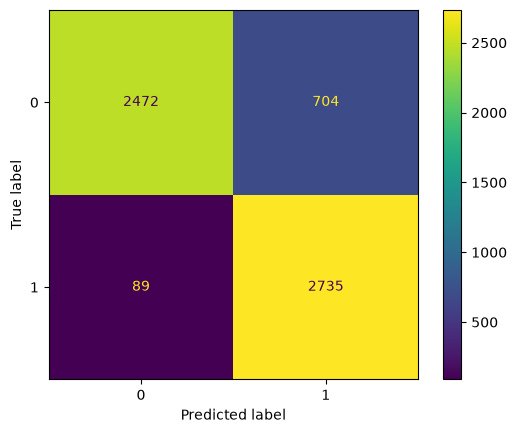

In [201]:
# 
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,MinMaxScaler,MaxAbsScaler

x = df['mail']
y = df['label']
xx_train,xx_test,yy_train,yy_test = train_test_split(x,y, test_size=0.3,random_state=42,)

print(len(xx_train), len(yy_train))
print(len(xx_test), len(yy_test))

pipeline = Pipeline([
    ('tfidf_vectorizer',CountVectorizer()),
    ('random_forest_classifier',SVC(probability=True)),
])

pipeline.fit(xx_train, yy_train)
pred = pipeline.predict(xx_test)
print(classification_report(yy_test,pred))

rf_cm = ConfusionMatrixDisplay(confusion_matrix(yy_test,pred))
rf_cm.plot()
plt.show()

              precision    recall  f1-score   support

           0       0.98      0.96      0.97      3176
           1       0.96      0.98      0.97      2824

    accuracy                           0.97      6000
   macro avg       0.97      0.97      0.97      6000
weighted avg       0.97      0.97      0.97      6000



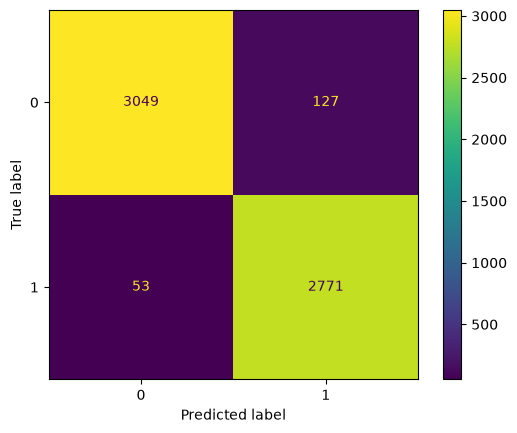

In [202]:
# 
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler

x = df["mail"]
y= df["label"]
xx_train, xx_test, yy_train, yy_test = train_test_split(x, y, test_size =0.3, random_state=42)

pipeline = Pipeline([
    ('tfidf_vectorizer',TfidfVectorizer()),
    ('randome_forest_classifier',SVC())
])

pipeline.fit(xx_train,yy_train)
pred = pipeline.predict(xx_test)
print(classification_report(yy_test,pred))

rf_cm = ConfusionMatrixDisplay(confusion_matrix(yy_test,pred))
rf_cm.plot()
plt.show()

#### Scaling data

In [203]:
# 
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [204]:
# 
scaled_acc = []
scaled_prec =[]
for name ,model in models.items():
    model.fit(x_train_scaled,y_train)
    scaled_pred = model.predict(x_test_scaled)
    scaled_acc.append(accuracy_score(y_test,scaled_pred))
    scaled_prec.append(precision_score(y_test,scaled_pred))

cv_score_df["scaled_precision"] = scaled_prec
cv_score_df["scaled_accuracy"] = scaled_acc
cv_score_df

,model,cv_precision,cv_accuracy,scaled_precision,scaled_accuracy
0,RandomForest,0.966206,0.957000,0.748535,0.826167
1,MultinomialNB,0.965873,0.920667,0.963606,0.894500
2,XGBoost,0.938957,0.956000,0.759815,0.829333
3,LogisticRegression,0.935915,0.953333,0.909001,0.941333
4,DecisionTree,0.895275,0.903000,0.784720,0.822500
5,GradientBoosting,0.875984,0.911333,0.875697,0.911167
6,SVM,0.792973,0.865667,0.938957,0.956000
7,AdaBoost,0.784720,0.822500,0.963702,0.955167
8,GaussianNB,0.761386,0.833500,0.776172,0.841500
9,BernoulliNB,0.759815,0.829333,0.897226,0.901667


              precision    recall  f1-score   support

           0       0.95      0.88      0.91      3176
           1       0.88      0.94      0.91      2824

    accuracy                           0.91      6000
   macro avg       0.91      0.91      0.91      6000
weighted avg       0.91      0.91      0.91      6000



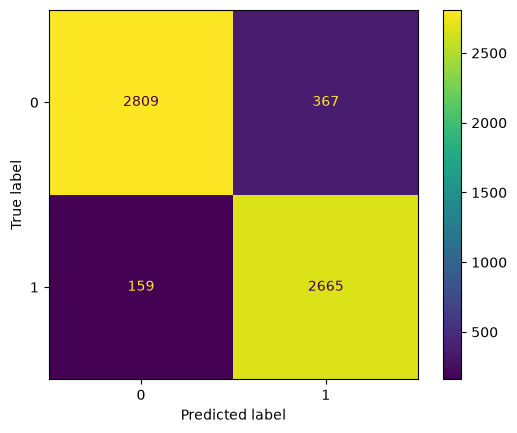

In [205]:
# 
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler

x = df["mail"]
y= df["label"]
xx_train, xx_test, yy_train, yy_test = train_test_split(x, y, test_size =0.3, random_state=42)

pipeline = Pipeline([
    ('tfidf_vectorizer',TfidfVectorizer()),
    ('minmax',MaxAbsScaler()),
    ('random_forest_classifier',GradientBoostingClassifier())
])

pipeline.fit(xx_train,yy_train)
pred = pipeline.predict(xx_test)
print(classification_report(yy_test,pred))

rf_cm =ConfusionMatrixDisplay(confusion_matrix(yy_test,pred))
rf_cm.plot()
plt.show()

In [206]:
# df['text'][2]

In [207]:
# " ".join(re.findall(r"(?u)\b\w\w+\b", df["text"][2]))

### Applying TF-IDF Vectorization

In [208]:
tf_df = pd.read_csv('../spam_Emails_data.csv',nrows=20000)
tf_df.head()

,label,text
0,Spam,viiiiiiagraaaa\nonly for the ones that want to...
1,Ham,got ice thought look az original message ice o...
2,Spam,yo ur wom an ne eds an escapenumber in ch ma n...
3,Spam,start increasing your odds of success & live s...
4,Ham,author jra date escapenumber escapenumber esca...


In [209]:
tf_df['label'].value_counts()

label
Ham     10592
Spam     9408
Name: count, dtype: int64

In [210]:
le = LabelEncoder()
tf_df['label'] = le.fit_transform(tf_df['label'])

In [211]:
tf_df['label'].value_counts()

label
0    10592
1     9408
Name: count, dtype: int64

In [212]:
tf_df.duplicated().sum()

np.int64(0)

In [213]:
tf_df.isnull().sum()

label    0
text     0
dtype: int64

In [214]:
from nltk.stem import PorterStemmer ,WordNetLemmatizer
wnl = WordNetLemmatizer()

# One Function for all text preprocessing 
def tf_text_preprocessing(text):
    text = text.lower()
    tokens = text.split()

    process_words = []
    for token in tokens:
        # Handle contractions
        if token in Words_dict:
            process_words.append(Words_dict[token])
        else:
            process_words.append(token)

    #  Lemmatization
    process_words = " ".join(process_words)
    token1 = wnl.lemmatize(process_words, pos='v')
    token2 = wnl.lemmatize(token1, pos='n')
    token3 = wnl.lemmatize(token2, pos='a')
    digit_remove = re.sub(r"\d+","",token3)

    # Handling repeating words by allowing only 2 time repeatation
    final_output = re.sub(r"(.)\1{3, }",r"\1\1",digit_remove)
    final_text = re.sub(r"\s+"," ",final_output)
    return final_text.strip()

In [215]:
tf_df["text"][5045]

'attn - sir\nhague questry lottery\nbonpostraat 26\n7651 am groningen\nthe netherlands .\nfrom : the desk of the promotions manager ,\ninternational promotions / prize award department ,\nref : tlot / 33900560 / 04\nbatch : 24 / ai 90061 / 8482 / ui\nattention :\nre / award notification ; final notice\nwe are pleased to inform you of the announcement today , 8 th october , 2004\nof winners of the the hague questry promo lottery , the netherlands /\ninternational , programs held on 28 th september , 2004 .\nyour email address , is attached to a ticket number , with serial number 4399 - 11 and the\nlucky numbers preserved and insured\nfor strict award distinct , identifying your lottery award in the 3 rd category\nyou have therefore been approved for a lump sum pay out of\nus $ 5 , 500 . 000 . 00 in cash credited to file ref no . tlot / 33900560 / 04 . this is from\ntotal prize money of us $ 80 , 400 , 000 . 00 shared among the seventeen\ninternational winners in this category . all part

In [216]:
tf_df["p_text"] = tf_df["text"].apply(tf_text_preprocessing)
tf_df["p_text"][5045]

'attn - sir hague questry lottery bonpostraat am groningen the netherlands . from : the desk of the promotions manager , international promotions / prize award department , reference : tlot / / batch : / ai / / ui attention : re / award notification ; final notice we are pleased to inform you of the announcement today , th october , of winners of the the hague questry promotion lottery , the netherlands / international , programs held on th september , . your email address , is attached to a ticket number , with serial number - and the lucky numbers preserved and insured for strict award distinct , identifying your lottery award inch the third category you have therefore been approved for a lump sum pay out of us $ , . . inch cash credited to file reference no . tlot / / . this is from total prize money of us $ , , . shared among the seventeen international winners inch this category . all participants were selected through a computer ballot system drawn from , names from aust ralia , 

In [217]:
words_corpus = [x for x in tf_df['p_text'].str.split()]
len(words_corpus)

20000

In [218]:
x = tf_df['p_text']
tv = TfidfVectorizer(ngram_range=(1,2),
                     max_features= 300,
                     min_df=2,
                     max_df=0.95,
                     strip_accents='ascii',
                     analyzer='word',
                     stop_words='english',
                     token_pattern= r"(?u)\b\w\w+b")

tv_array  = tv.fit_transform(x).toarray()
tv_df = pd.DataFrame(tv_array,columns=tv.get_feature_names_out())
tv_df.shape

/Users/fahimp/Desktop/Python_Frameworks/NLP/email_spam-harm/spamORharm/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:412: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['describ', 'hereb', 'nob', 'thereb', 'whereb'] not in stop_words.
  warnings.warn(


(20000, 300)

In [219]:
tv_df.head()

,abb,acceptab,accessib,acrob,acrob escapenumb,adob,adob acrob,adob escapenumb,aescapenumb,aescapenumb aescapenumb,...,vescapenumb escapenumb,web,web escapenumb,web pub,web sub,web web,xescapenumb,xescapenumb escapenumb,zescapenumb,zescapenumb escapenumb
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.029019,0.0,0.0,0.0,0.022682,0.0,0.0,0.0,0.0


In [220]:
x_train,x_test,y_train,y_test = train_test_split(tv_df,tf_df['label'],test_size=0.3,random_state=42)

In [221]:
models = {
    "GaussianNB": GaussianNB(),
    "MultinomialNB": MultinomialNB(),
    "BernoulliNB": BernoulliNB(),
    "LogisticRegression": LogisticRegression(max_iter=5000),
    "AdaBoost": AdaBoostClassifier(),
    "GradientBoosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(),
    "RandomForest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "DecisionTree": DecisionTreeClassifier(),
    "SVM": SVC()
}

accuracy = []
precision = []

for name, model in models.items():
    model.fit(x_train,y_train)
    pred = model.predict(x_test)
    accuracy.append(accuracy_score(y_test,pred))
    precision.append(precision_score(y_test,pred))

tv_score_df = pd.DataFrame({'model':models.keys(),'tv_precision':precision,'tv_accuracy':accuracy})
tv_score_df = tv_score_df.sort_values(by='tv_precision',ascending=False).reset_index(drop = True)
tv_score_df

,model,tv_precision,tv_accuracy
0,RandomForest,0.787528,0.827500
1,MultinomialNB,0.785453,0.711167
2,XGBoost,0.762534,0.820833
3,DecisionTree,0.759872,0.799167
4,SVM,0.752530,0.803833
5,LogisticRegression,0.749334,0.779000
6,KNN,0.740696,0.794500
7,GradientBoosting,0.717220,0.786667
8,BernoulliNB,0.695969,0.762667
9,GaussianNB,0.692455,0.764000


### Applying Logistic Regression

              precision    recall  f1-score   support

           0       0.81      0.76      0.79      3176
           1       0.75      0.80      0.77      2824

    accuracy                           0.78      6000
   macro avg       0.78      0.78      0.78      6000
weighted avg       0.78      0.78      0.78      6000



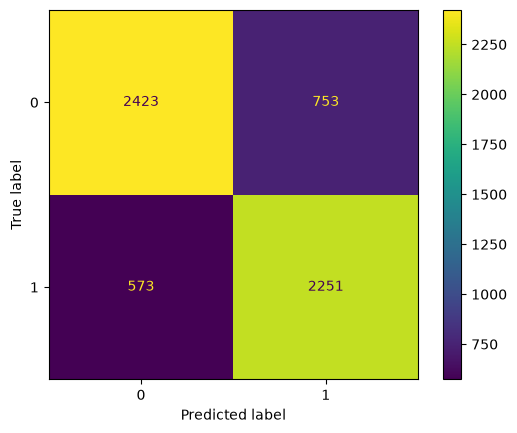

In [222]:
lr = LogisticRegression(max_iter = 10000)
lr.fit(x_train,y_train)
pred = lr.predict(x_test)
print(classification_report(y_test,pred))

lr_cm = ConfusionMatrixDisplay(confusion_matrix(y_test,pred))
lr_cm.plot()
plt.show()

              precision    recall  f1-score   support

           0       0.97      0.96      0.97      3176
           1       0.96      0.97      0.96      2824

    accuracy                           0.97      6000
   macro avg       0.96      0.97      0.97      6000
weighted avg       0.97      0.97      0.97      6000



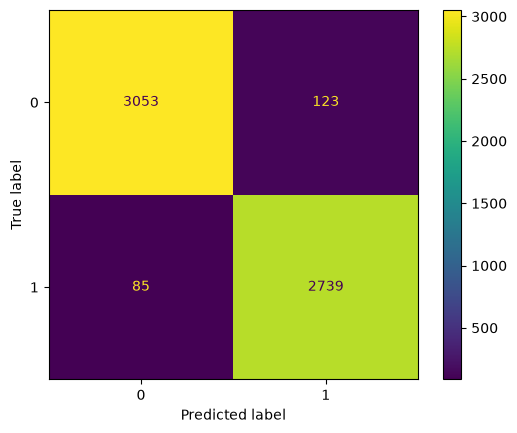

Precision:  0.9570230607966457


In [223]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler,MaxAbsScaler

x = tf_df['p_text']
y = tf_df['label']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3 ,random_state=42)

pipeline = Pipeline([
    ('tfidf_vectorizer',TfidfVectorizer(ngram_range=(1,2),
                                        max_features = 10000,
                                        min_df = 2,
                                        max_df = 0.95,
                                        strip_accents = 'ascii',
                                        analyzer = 'word',
                                        stop_words = 'english',
                                        token_pattern = r"(?u)\b\w\w+\b")),
    ('MinMaxScaler',MaxAbsScaler()),
    ('random_forest_classifier',LogisticRegression(max_iter=10000,tol=0.0001,solver='saga'))
])

pipeline.fit(x_train,y_train)
pred = pipeline.predict(x_test)
print(classification_report(y_test,pred))
rf_cm = ConfusionMatrixDisplay(confusion_matrix(y_test,pred))
rf_cm.plot()
plt.show()
print('Precision: ',precision_score(y_test,pred))

In [224]:
import pickle
# pickle.dump(pipeline,open('LR_TF_pipeline.pkl','wb'))

### Applying Random Forest Classifier

              precision    recall  f1-score   support

           0       0.96      0.78      0.86      3176
           1       0.80      0.96      0.87      2824

    accuracy                           0.87      6000
   macro avg       0.88      0.87      0.87      6000
weighted avg       0.88      0.87      0.87      6000



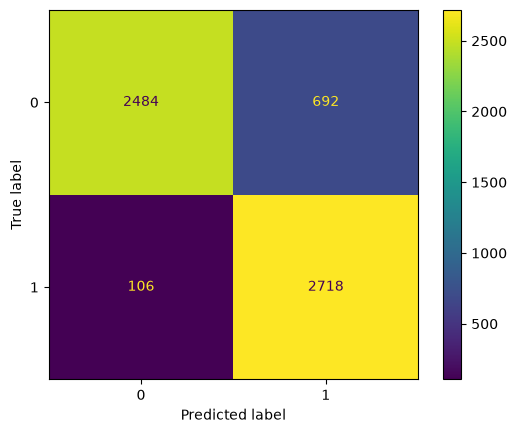

Precision:  0.797067448680352


In [225]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler

x = tf_df["p_text"]
y= tf_df["label"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size =0.3, random_state=42)

pipeline = Pipeline([
    ("tfidf_vectorizer", TfidfVectorizer(ngram_range = (1,2),
                                            max_features = 10000,
                                            min_df = 2,
                                            max_df = 0.95,
                                            strip_accents = "ascii",
                                            analyzer = "word",
                                            stop_words = "english",
                                            token_pattern = r"(?u)\b\w\w+\b")),
    
    ("MinMaxScaling", MaxAbsScaler()),
    ("random_forest_classifier", RandomForestClassifier(n_estimators = 300,
                                                       max_depth = 7,
                                                       min_samples_split = 5,
                                                       min_samples_leaf = 5,
                                                       warm_start = True))])

pipeline.fit(x_train, y_train)
pred = pipeline.predict(x_test)
print(classification_report(y_test, pred))
rf_cm = ConfusionMatrixDisplay(confusion_matrix(y_test, pred))
rf_cm.plot()
plt.show()

print("Precision: ", precision_score(y_test, pred))


### Support Vectore Classifier

              precision    recall  f1-score   support

           0       0.98      0.96      0.97      3176
           1       0.96      0.98      0.97      2824

    accuracy                           0.97      6000
   macro avg       0.97      0.97      0.97      6000
weighted avg       0.97      0.97      0.97      6000



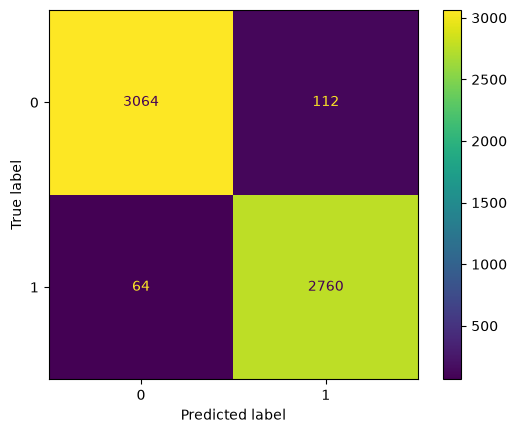

Precision:  0.9610027855153204


In [226]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler

x = tf_df["p_text"]
y= tf_df["label"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size =0.3, random_state=42)

pipeline = Pipeline([
    ("tfidf_vectorizer", TfidfVectorizer(ngram_range = (1,2),
                                            max_features = 8000,
                                            min_df = 2,
                                            max_df = 0.95,
                                            strip_accents = "ascii",
                                            analyzer = "word",
                                            stop_words = "english",
                                            token_pattern = r"(?u)\b\w\w+\b")),
    #("MinMaxScaling", MaxAbsScaler()),
    ("random_forest_classifier", SVC())])

pipeline.fit(x_train, y_train)
pred = pipeline.predict(x_test)
print(classification_report(y_test, pred))
rf_cm = ConfusionMatrixDisplay(confusion_matrix(y_test, pred))
rf_cm.plot()
plt.show()

print("Precision: ", precision_score(y_test, pred))


In [227]:
pickle.dump(pipeline,open('SVM_TF_pipeline.pkl','wb'))

### Gradient Boost Classifier

              precision    recall  f1-score   support

           0       0.96      0.91      0.94      3176
           1       0.91      0.96      0.93      2824

    accuracy                           0.94      6000
   macro avg       0.94      0.94      0.94      6000
weighted avg       0.94      0.94      0.94      6000



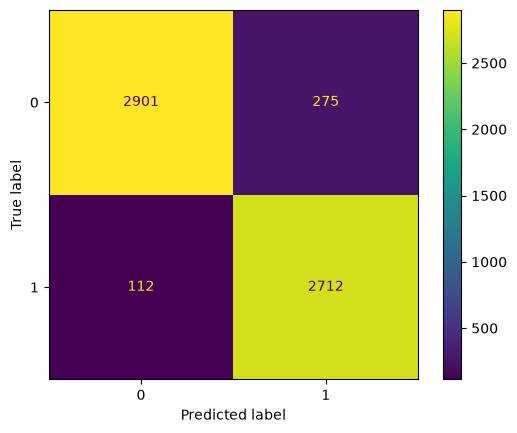

Precision:  0.9079343823234014


In [228]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler

x = tf_df["p_text"]
y= tf_df["label"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size =0.3, random_state=42)

pipeline = Pipeline([
    ("tfidf_vectorizer", TfidfVectorizer(ngram_range = (1,2),
                                            max_features = 10000,
                                            min_df = 2,
                                            max_df = 0.95,
                                            strip_accents = "ascii",
                                            analyzer = "word",
                                            stop_words = "english",
                                            token_pattern = r"(?u)\b\w\w+\b")),
    
    ("MinMaxScaling", MaxAbsScaler()),
    ("random_forest_classifier", GradientBoostingClassifier(n_estimators = 200,
                                                           warm_start = True,
                                                           learning_rate = 0.1,
                                                           max_depth = 5,
                                                           min_impurity_decrease = 0.0001))])

pipeline.fit(x_train, y_train)
pred = pipeline.predict(x_test)
print(classification_report(y_test, pred))
rf_cm = ConfusionMatrixDisplay(confusion_matrix(y_test, pred))
rf_cm.plot()
plt.show()

print("Precision: ", precision_score(y_test, pred))

### AdaBoost Classifier

              precision    recall  f1-score   support

           0       0.88      0.82      0.85      3176
           1       0.81      0.88      0.84      2824

    accuracy                           0.85      6000
   macro avg       0.85      0.85      0.85      6000
weighted avg       0.85      0.85      0.85      6000



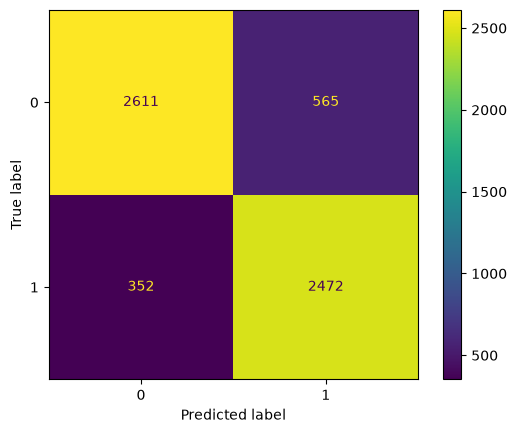

Precision:  0.8139611458676326


In [229]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler

x = tf_df["p_text"]
y= tf_df["label"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size =0.3, random_state=42)

pipeline = Pipeline([
    ("tfidf_vectorizer", TfidfVectorizer(ngram_range = (1,2),
                                            max_features = 8000,
                                            min_df = 2,
                                            max_df = 0.95,
                                            strip_accents = "ascii",
                                            analyzer = "word",
                                            stop_words = "english",
                                            token_pattern = r"(?u)\b\w\w+\b")),
    
    ("MinMaxScaling", MaxAbsScaler()),
    ("random_forest_classifier", AdaBoostClassifier())])

pipeline.fit(x_train, y_train)
pred = pipeline.predict(x_test)
print(classification_report(y_test, pred))
rf_cm = ConfusionMatrixDisplay(confusion_matrix(y_test, pred))
rf_cm.plot()
plt.show()

print("Precision: ", precision_score(y_test, pred))

### XGB Classifier

              precision    recall  f1-score   support

           0       0.97      0.94      0.96      3176
           1       0.94      0.97      0.95      2824

    accuracy                           0.95      6000
   macro avg       0.95      0.95      0.95      6000
weighted avg       0.95      0.95      0.95      6000



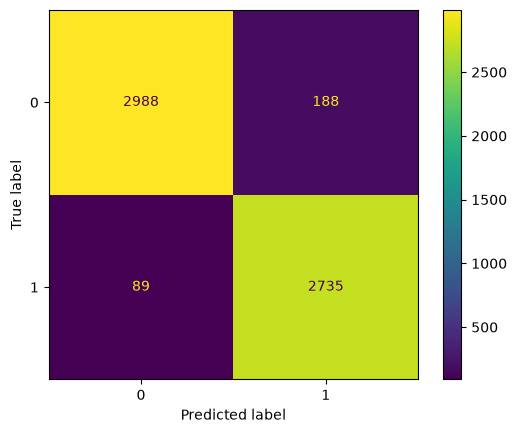

Precision:  0.935682517960999


In [230]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler

x = tf_df["p_text"]
y= tf_df["label"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size =0.3, random_state=42)

pipeline = Pipeline([
    ("tfidf_vectorizer", TfidfVectorizer(ngram_range = (1,2),
                                            max_features = 8000,
                                            min_df = 2,
                                            max_df = 0.95,
                                            strip_accents = "ascii",
                                            analyzer = "word",
                                            stop_words = "english",
                                            token_pattern = r"(?u)\b\w\w+\b")),
    
    #("MinMaxScaling", MaxAbsScaler()),
    ("random_forest_classifier", XGBClassifier())])

pipeline.fit(x_train, y_train)
pred = pipeline.predict(x_test)
print(classification_report(y_test, pred))
rf_cm = ConfusionMatrixDisplay(confusion_matrix(y_test, pred))
rf_cm.plot()
plt.show()

print("Precision: ", precision_score(y_test, pred))

In [231]:
# 
from sklearn.preprocessing import MinMaxScaler
x_train, x_test, y_train, y_test = train_test_split(tv_df, df["label"], test_size=0.3, random_state=42)

scaler = MinMaxScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


In [232]:
# 
scaled_acc = []
scaled_prec = []
for name, model in models.items():
    model.fit(x_train_scaled, y_train)
    scaled_pred = model.predict(x_test_scaled)
    scaled_acc.append(accuracy_score(y_test, scaled_pred))
    scaled_prec.append(precision_score(y_test, scaled_pred))

tv_score_df["scaled_precision"] = scaled_prec
tv_score_df["scaled_accuracy"] = scaled_acc
tv_score_df


,model,tv_precision,tv_accuracy,scaled_precision,scaled_accuracy
0,RandomForest,0.787528,0.827500,0.694766,0.765000
1,MultinomialNB,0.785453,0.711167,0.793881,0.711833
2,XGBoost,0.762534,0.820833,0.695969,0.762667
3,DecisionTree,0.759872,0.799167,0.751378,0.787833
4,SVM,0.752530,0.803833,0.641850,0.710333
5,LogisticRegression,0.749334,0.779000,0.717220,0.786667
6,KNN,0.740696,0.794500,0.762534,0.820833
7,GradientBoosting,0.717220,0.786667,0.787810,0.826833
8,BernoulliNB,0.695969,0.762667,0.737908,0.791667
9,GaussianNB,0.692455,0.764000,0.755788,0.798167


### Appying Word2Vec text vetorizer of nltk.gensim

In [233]:
from nltk.tokenize import word_tokenize, sent_tokenize
word_corpus = df["mail"].apply(lambda x: word_tokenize(x))

wv_model = Word2Vec(window = 3, min_count = 1, vector_size=300)
wv_model.build_vocab(word_corpus)
wv_model.train(word_corpus, total_examples = wv_model.corpus_count, epochs = wv_model.epochs)

(17133762, 26188970)

In [234]:
wv_model.wv.most_similar("good")

[('uninspiring', 0.5900182127952576),
 ('great', 0.5825147032737732),
 ('wescapenumberm', 0.5490337014198303),
 ('bad', 0.5353310108184814),
 ('fine', 0.5282158255577087),
 ('though', 0.5025525689125061),
 ('normal', 0.4947584569454193),
 ('nice', 0.49171483516693115),
 ('comfortable', 0.48878607153892517),
 ('well', 0.48389706015586853)]

In [235]:
# all Vectors
wv_model.wv.get_normed_vectors()

array([[-0.00962896,  0.02915382,  0.08622232, ...,  0.06663448,
         0.02727221, -0.03542241],
       [-0.00362643,  0.03564889, -0.03396968, ..., -0.10172302,
        -0.00268327,  0.08072858],
       [-0.08644933,  0.0296039 , -0.05058808, ..., -0.02512144,
         0.09032109,  0.0421963 ],
       ...,
       [ 0.03955585, -0.00406563, -0.06119576, ..., -0.0685759 ,
        -0.0037775 ,  0.03271064],
       [ 0.02812432, -0.01756229, -0.04764417, ..., -0.09621383,
         0.02763783, -0.00803053],
       [ 0.02918352, -0.01680859, -0.02334847, ..., -0.07596182,
         0.01040298, -0.01370843]], shape=(137084, 300), dtype=float32)

In [236]:
wv_model.wv.get_normed_vectors().shape

(137084, 300)

In [237]:
# our dataset vocabulary
wv_model.wv.index_to_key[:10]

['escapenumber',
 'escapelong',
 'com',
 'http',
 'be',
 'see',
 'message',
 'language',
 'would',
 'enron']

In [238]:
len(wv_model.wv.index_to_key)

137084

### We convert a sentence into one vector by averaging word vectors

In [239]:
def sentence_vector(tokens):
    vectors = []
    for word in tokens:
        if word in wv_model.wv:
            vectors.append(wv_model.wv[word])
    if len(vectors)>0:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(300)

In [240]:
wv_df= np.vstack(word_corpus.apply(sentence_vector))
wv_df.shape

(20000, 300)